# 15 TCN Low-Vol Weighting and Calibration

This notebook focuses on one specific weakness in the sequence models: they tend to keep the volatility valleys too high.

The experiments here try two direct fixes:

1. `low-vol weighted loss`: force the TCN to care more about low-volatility examples during training,
2. `low-vol calibration`: apply calibration only where the raw predictions are already in the low-volatility region.

The goal is not to maximize one global metric at any cost, but to see whether the model can get the valleys down more naturally.

In [1]:
from pathlib import Path
import copy
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Baseline setup

This notebook keeps the same fast-current feature family and nearly the same TCN structure as notebook 13.

That way, if the valleys improve, the change is more clearly due to low-vol weighting or low-vol calibration rather than a hidden architecture shift.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

fast_current_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

model_config = {
    'lookback': 90,
    'channels': [64, 64, 64, 64],
    'kernel_size': 3,
    'dropout': 0.25,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 20,
    'patience': 5,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

experiment_df = model_df[target_columns + fast_current_features].copy()
train_mask = experiment_df['Date'].dt.year <= train_end_year
low_vol_threshold = float(experiment_df.loc[train_mask, 'fvol_5d'].quantile(0.20))
weight_configs = [
    {'name': 'baseline_tcn_mse', 'loss_name': 'mse', 'low_weight': 1.0},
    {'name': 'low_vol_weighted_tcn', 'loss_name': 'weighted_mse', 'low_weight': 3.0},
]

pd.DataFrame(weight_configs)

,name,loss_name,low_weight
0,baseline_tcn_mse,mse,1.0
1,low_vol_weighted_tcn,weighted_mse,3.0


## Dataset, TCN, and metrics

The extra diagnostics below matter most for this notebook:

- `low_vol_mae`: error inside the lowest-volatility quintile,
- `low_vol_bias`: mean(prediction - actual) in that same region.

A lower positive bias means the valleys are being lifted less.

In [3]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        return {
            'x': torch.tensor(panel['features'][start_idx:end_idx + 1], dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'sample_weight': torch.tensor(panel['sample_weight'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.left_padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)

    def forward(self, x):
        x = nn.functional.pad(x, (self.left_padding, 0))
        return self.conv(x)

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=dilation)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.dropout(self.activation(self.conv1(x)))
        out = self.dropout(self.activation(self.conv2(out)))
        return self.activation(out + residual)

class TCNVolatilityModel(nn.Module):
    def __init__(self, input_dim, num_tickers, channels, kernel_size, dropout, ticker_embedding_dim):
        super().__init__()
        layers = []
        in_channels = input_dim
        for i, out_channels in enumerate(channels):
            layers.append(TemporalBlock(in_channels, out_channels, kernel_size, dilation=2**i, dropout=dropout))
            in_channels = out_channels
        self.tcn = nn.Sequential(*layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(channels[-1] + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = x.transpose(1, 2)
        encoded = self.tcn(x)
        seq_repr = encoded[:, :, -1]
        ticker_repr = self.ticker_embedding(ticker_idx)
        return self.head(torch.cat([seq_repr, ticker_repr], dim=1)).squeeze(-1)

def prepare_data(feature_list, lookback, batch_size, low_weight):
    panel_df = experiment_df.copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = panel_df['Date'].dt.year <= train_end_year
    feature_mean = panel_df.loc[train_mask, feature_list].mean()
    feature_std = panel_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    panel_df[feature_list] = (panel_df[feature_list] - feature_mean) / feature_std
    panel_df['sample_weight'] = np.where(panel_df['fvol_5d'] <= low_vol_threshold, low_weight, 1.0)
    ticker_levels = sorted(panel_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped = {}
    for ticker, group in panel_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
            'sample_weight': group['sample_weight'].to_numpy(dtype=np.float32),
        }
    return {
        'num_tickers': len(ticker_levels),
        'train_loader': DataLoader(RollingSequenceDataset(grouped, ticker_to_idx, lookback, range(2016, train_end_year + 1)), batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(RollingSequenceDataset(grouped, ticker_to_idx, lookback, [validation_year]), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(RollingSequenceDataset(grouped, ticker_to_idx, lookback, [test_year]), batch_size=batch_size, shuffle=False, num_workers=0),
    }

def run_epoch(model, dataloader, loss_name='mse', optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        sample_weight = batch['sample_weight'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            sq_error = (pred - y_log) ** 2
            if loss_name == 'weighted_mse':
                loss = torch.mean(sample_weight * sq_error)
            else:
                loss = torch.mean(sq_error)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        actual_vol = batch['y_vol'].numpy()
        for date, ticker, actual, pred in zip(batch['date'], batch['ticker'], actual_vol, pred_vol):
            rows.append({'Date': pd.to_datetime(date), 'Ticker': ticker, 'fvol_5d': float(actual), 'prediction': float(pred)})
    return pd.DataFrame(rows)

def evaluate(prediction_df):
    y_true = np.asarray(prediction_df['fvol_5d'], dtype=float)
    y_pred = np.clip(np.asarray(prediction_df['prediction'], dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    low_cut = np.quantile(y_true, 0.20)
    low_mask = y_true <= low_cut
    low_errors = y_pred[low_mask] - y_true[low_mask]
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
        'low_vol_mae': float(np.mean(np.abs(low_errors))),
        'low_vol_bias': float(np.mean(low_errors)),
    }

def selective_linear_calibration(val_df, test_df):
    val_cut_actual = np.quantile(val_df['fvol_5d'], 0.30)
    subset = val_df[val_df['fvol_5d'] <= val_cut_actual].copy()
    pred_cut = subset['prediction'].quantile(0.75)
    calibrator = LinearRegression()
    calibrator.fit(subset[['prediction']], subset['fvol_5d'])
    adjusted = test_df.copy()
    mask = adjusted['prediction'] <= pred_cut
    adjusted.loc[mask, 'prediction'] = calibrator.predict(adjusted.loc[mask, ['prediction']]).clip(1e-8)
    return adjusted, {'pred_cut': float(pred_cut), 'val_cut_actual': float(val_cut_actual)}

def selective_isotonic_calibration(val_df, test_df):
    val_cut_actual = np.quantile(val_df['fvol_5d'], 0.30)
    subset = val_df[val_df['fvol_5d'] <= val_cut_actual].copy().sort_values('prediction')
    pred_cut = subset['prediction'].quantile(0.75)
    calibrator = IsotonicRegression(out_of_bounds='clip', increasing=True)
    calibrator.fit(subset['prediction'], subset['fvol_5d'])
    adjusted = test_df.copy()
    mask = adjusted['prediction'] <= pred_cut
    adjusted.loc[mask, 'prediction'] = calibrator.predict(adjusted.loc[mask, 'prediction']).clip(1e-8)
    return adjusted, {'pred_cut': float(pred_cut), 'val_cut_actual': float(val_cut_actual)}


## Train baseline and low-vol weighted TCN

The weighted model only changes the training loss. Everything else stays the same.

In [4]:
results = []
predictions = {}
histories = {}

for config in weight_configs:
    print(f"\n=== {config['name']} ===")
    data = prepare_data(fast_current_features, model_config['lookback'], model_config['batch_size'], config['low_weight'])
    model = TCNVolatilityModel(
        input_dim=len(fast_current_features),
        num_tickers=data['num_tickers'],
        channels=model_config['channels'],
        kernel_size=model_config['kernel_size'],
        dropout=model_config['dropout'],
        ticker_embedding_dim=model_config['ticker_embedding_dim'],
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=model_config['learning_rate'], weight_decay=model_config['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, model_config['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], loss_name=config['loss_name'], optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], loss_name='mse', optimizer=None)
        history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        print(f"epoch {epoch}/{model_config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= model_config['patience']:
            print(f"early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    histories[config['name']] = pd.DataFrame(history_rows)
    val_pred = predict_dataset(model, data['val_loader'])
    test_pred = predict_dataset(model, data['test_loader'])
    predictions[config['name']] = {'val': val_pred, 'test': test_pred}
    results.append({'model': config['name'], 'split': 'validation', **evaluate(val_pred), 'best_epoch': best_epoch})
    results.append({'model': config['name'], 'split': 'test', **evaluate(test_pred), 'best_epoch': best_epoch})

results_df = pd.DataFrame(results)
results_df


=== baseline_tcn_mse ===


epoch 1/20 | train_loss=0.711766 | val_loss=0.245470


epoch 2/20 | train_loss=0.250217 | val_loss=0.238537


epoch 3/20 | train_loss=0.237938 | val_loss=0.247270


epoch 4/20 | train_loss=0.230045 | val_loss=0.236521


...

epoch 4/20 | train_loss=0.364642 | val_loss=0.250880


epoch 5/20 | train_loss=0.352374 | val_loss=0.251995


epoch 6/20 | train_loss=0.343763 | val_loss=0.254989


epoch 7/20 | train_loss=0.337824 | val_loss=0.258364
early stopping at epoch 7. Best epoch: 2.


,model,split,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias,best_epoch
0,baseline_tcn_mse,validation,0.140555,0.082287,-1.639844,0.463206,0.072313,0.071035,6
1,baseline_tcn_mse,test,0.161828,0.095699,-1.364961,0.498180,0.076547,0.075319,6
2,low_vol_weighted_tcn,validation,0.144922,0.083539,-1.480429,0.442420,0.061622,0.059628,2
3,low_vol_weighted_tcn,test,0.163011,0.097124,-1.279078,0.507639,0.066425,0.063768,2


## Low-vol selective calibration

The calibration is deliberately local. It only changes predictions that already sit in the lower predicted-volatility region, instead of shifting the whole curve.

In [5]:
val_low_vol_summary = results_df[results_df['split'] == 'validation'][['model', 'low_vol_mae', 'low_vol_bias']].sort_values('low_vol_mae')
best_uncalibrated_name = str(val_low_vol_summary.iloc[0]['model'])
best_val_df = predictions[best_uncalibrated_name]['val']
best_test_df = predictions[best_uncalibrated_name]['test']

linear_calibrated_df, linear_meta = selective_linear_calibration(best_val_df, best_test_df)
isotonic_calibrated_df, isotonic_meta = selective_isotonic_calibration(best_val_df, best_test_df)

calibration_results_df = pd.DataFrame([
    {'model': best_uncalibrated_name, **evaluate(best_test_df)},
    {'model': 'low_vol_linear_calibrated', **evaluate(linear_calibrated_df)},
    {'model': 'low_vol_isotonic_calibrated', **evaluate(isotonic_calibrated_df)},
])
calibration_results_df

,model,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias
0,low_vol_weighted_tcn,0.163011,0.097124,-1.279078,0.507639,0.066425,0.063768
1,low_vol_linear_calibrated,0.168853,0.104163,-0.782393,0.503561,0.052826,0.041662
2,low_vol_isotonic_calibrated,0.168510,0.103676,-0.823863,0.504703,0.052565,0.041704


In [6]:
pd.DataFrame([
    {'calibration': 'linear', **linear_meta},
    {'calibration': 'isotonic', **isotonic_meta},
])

,calibration,pred_cut,val_cut_actual
0,linear,0.180359,0.141553
1,isotonic,0.180359,0.141553


## Plot the strongest low-vol variant

The final plot compares the best uncalibrated model with the best calibrated version by `test low_vol_mae`.

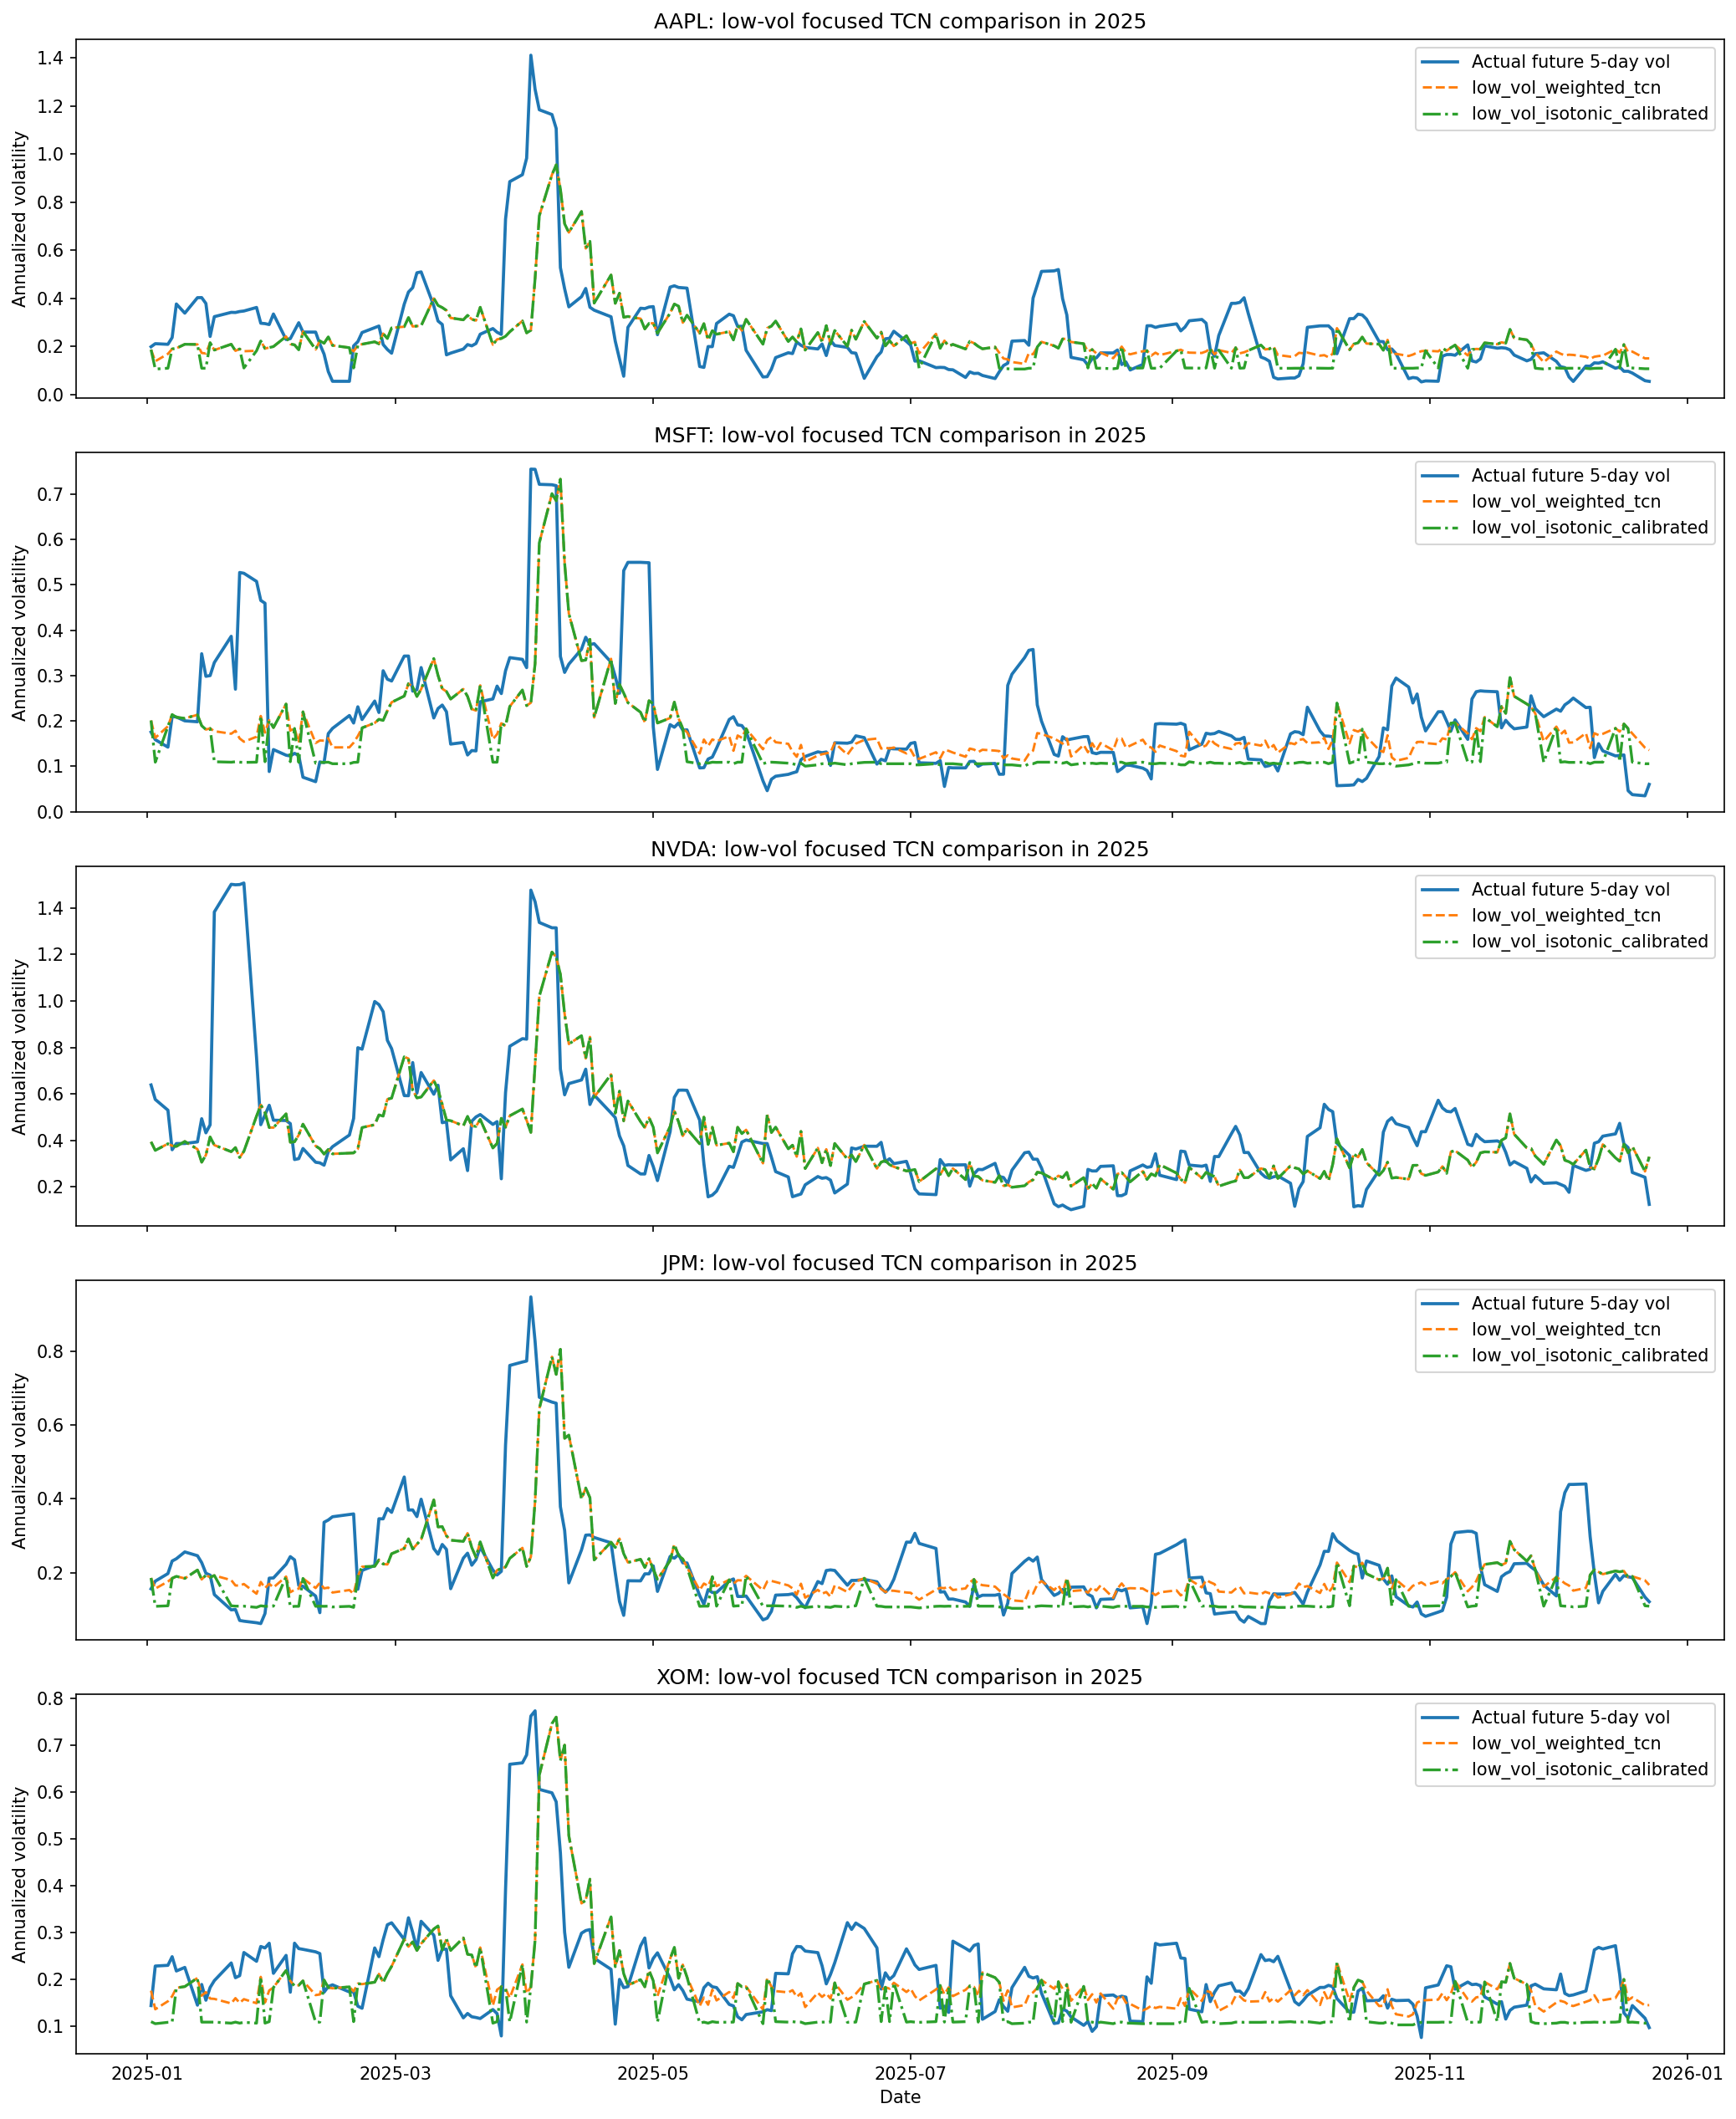

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/tcn_low_vol_focus_5stocks.png')

In [7]:
calibration_choice_df = calibration_results_df.sort_values('low_vol_mae').reset_index(drop=True)
best_final_name = str(calibration_choice_df.iloc[0]['model'])
if best_final_name == best_uncalibrated_name:
    best_final_predictions = best_test_df.copy()
elif best_final_name == 'low_vol_linear_calibrated':
    best_final_predictions = linear_calibrated_df.copy()
else:
    best_final_predictions = isotonic_calibrated_df.copy()

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 17), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    raw_plot_df = best_test_df[best_test_df['Ticker'] == ticker].sort_values('Date')
    final_plot_df = best_final_predictions[best_final_predictions['Ticker'] == ticker].sort_values('Date')
    ax.plot(raw_plot_df['Date'], raw_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(raw_plot_df['Date'], raw_plot_df['prediction'], label=f'{best_uncalibrated_name}', linestyle='--', linewidth=1.4)
    if best_final_name != best_uncalibrated_name:
        ax.plot(final_plot_df['Date'], final_plot_df['prediction'], label=best_final_name, linestyle='-.', linewidth=1.6)
    ax.set_title(f'{ticker}: low-vol focused TCN comparison in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / 'tcn_low_vol_focus_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path

## Interpretation guide

This notebook is successful if one of the low-vol methods lowers `low_vol_mae` and `low_vol_bias` without breaking the overall forecast too badly.